<a href="https://colab.research.google.com/github/tishamondal-stargazer/Machine-Learning/blob/main/Prac-10-Hierarchical-Extra/prac10_extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal

Lab 10 Extra Practical: To perform Hierarchical Clustering using agglomerative methods and interpret dendrograms for cluster formation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
url = "https://raw.githubusercontent.com/tishamondal-stargazer/Machine-Learning/refs/heads/main/datasets/Spotify_Songs_Dataset.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
print(df.shape)
print(df.columns)

df.info()
df.describe()

print(df.isnull().sum())

(114000, 21)
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy    

In [5]:
X = df[['tempo', 'energy', 'danceability']]
print(X.head())

     tempo  energy  danceability
0   87.917  0.4610         0.676
1   77.489  0.1660         0.420
2   76.332  0.3590         0.438
3  181.740  0.0596         0.266
4  119.949  0.4430         0.618


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

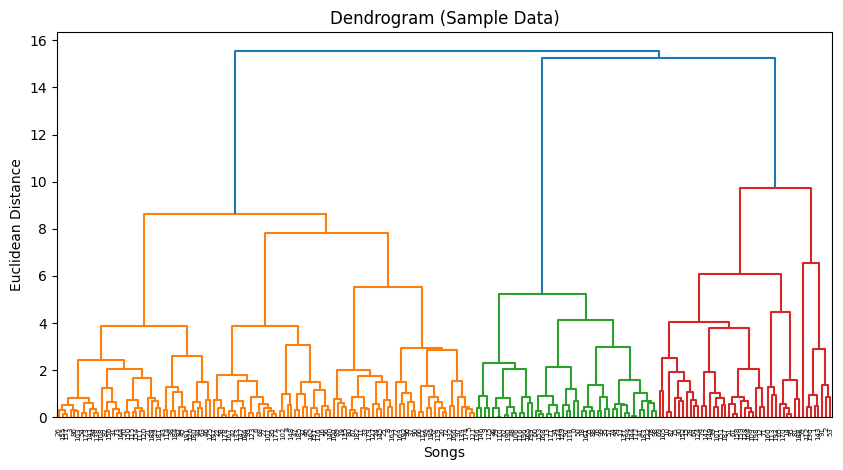

In [7]:
X_sample = pd.DataFrame(X_scaled).sample(n=200, random_state=42)

plt.figure(figsize=(10, 5))
dendrogram(linkage(X_sample, method='ward'))

plt.title("Dendrogram (Sample Data)")
plt.xlabel("Songs")
plt.ylabel("Euclidean Distance")

plt.show()

In [8]:
# Take sample to avoid crash
df_sample = df.sample(n=1000, random_state=42)

# Select features
X_sample = df_sample[['tempo', 'energy', 'danceability']]

# Scale features
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# Apply Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

clusters = hc.fit_predict(X_sample_scaled)

# Add cluster labels
df_sample['Cluster'] = clusters

df_sample.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,Cluster
113186,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,...,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music,1
42819,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,...,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore,1
59311,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,...,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian,0
91368,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,...,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock,2
61000,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,...,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol,2


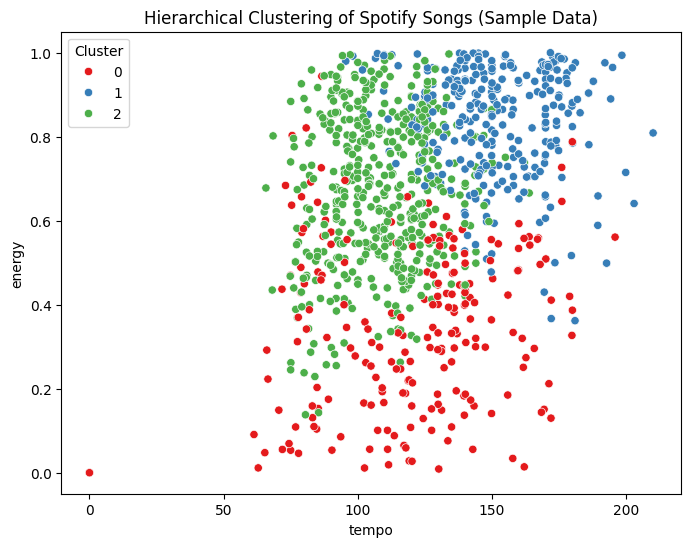

In [9]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='tempo',
    y='energy',
    hue='Cluster',
    data=df_sample,
    palette='Set1'
)

plt.title('Hierarchical Clustering of Spotify Songs (Sample Data)')
plt.show()

In [10]:
df_sample.groupby('Cluster')[['tempo', 'energy', 'danceability']].mean()

,tempo,energy,danceability
Cluster,,,
0,120.786014,0.345499,0.455244
1,151.251525,0.835395,0.467656
2,108.556346,0.669611,0.673762
